# Part 3: NLP and Sequence Modeling Mini Project

**Dataset:** Customer Support Text Classification Dataset  
**Task:** Multi-class sentiment classification (positive, neutral, negative)  
**Approach:** TF-IDF + Logistic Regression baseline → LSTM architecture design

---


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                              accuracy_score, f1_score)

plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')
print("Libraries loaded.")


Libraries loaded.


## Task 1: Dataset Understanding

In [11]:
df = pd.read_csv('customer_support_text_classification.csv')

print(f"Shape: {df.shape[0]} records × {df.shape[1]} columns")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nTarget label distribution:")
print(df['sentiment_label'].value_counts())
print(f"\nSample records:")
df[['customer_message', 'sentiment_label']].head(6)


Shape: 1500 records × 6 columns

Columns: ['ticket_id', 'channel', 'customer_message', 'sentiment_label', 'word_count', 'urgent_flag']

Target label distribution:
sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Sample records:


,customer_message,sentiment_label
0,I need information about the payment process. ...,neutral
1,I need information about the payment process.,neutral
2,The refund process was fast and convenient. I ...,positive
3,My refund is still pending and this experience...,negative
4,Please tell me how to update my account details.,neutral
5,I need help finding the invoice for my last or...,neutral


Average text length : 12.7 words
Min text length     : 7 words
Max text length     : 26 words

Missing values: 0


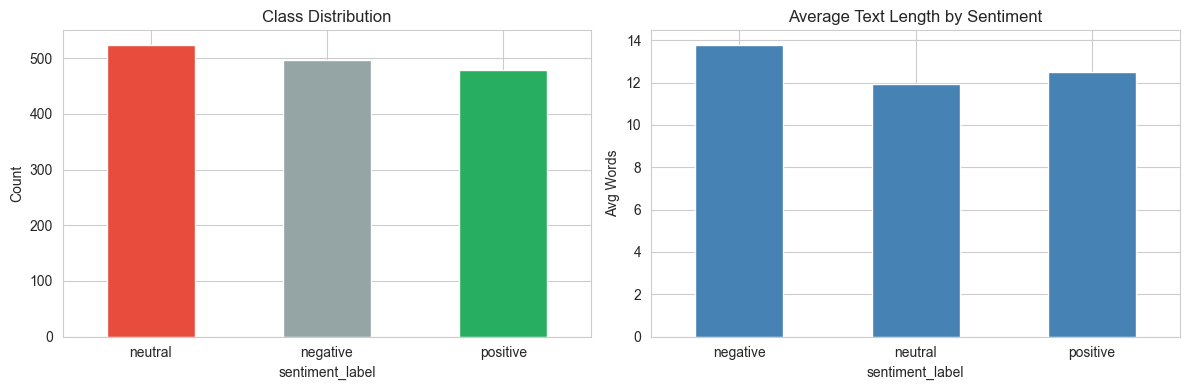

In [12]:
# Text length analysis
df['text_length'] = df['customer_message'].str.split().str.len()
print(f"Average text length : {df['text_length'].mean():.1f} words")
print(f"Min text length     : {df['text_length'].min()} words")
print(f"Max text length     : {df['text_length'].max()} words")
print(f"\nMissing values: {df.isnull().sum().sum()}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['sentiment_label'].value_counts().plot(kind='bar', ax=axes[0], color=['#e74c3c','#95a5a6','#27ae60'], edgecolor='white')
axes[0].set_title('Class Distribution'); axes[0].set_ylabel('Count'); axes[0].tick_params(axis='x', rotation=0)

df.groupby('sentiment_label')['text_length'].mean().plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Average Text Length by Sentiment'); axes[1].set_ylabel('Avg Words'); axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout(); plt.show()


## Task 2: Text Preprocessing

Steps applied:
1. Lowercase the text
2. Remove special characters and numbers
3. Strip extra whitespace
4. Tokenization (handled by vectorizers)
5. Stopword-aware TF-IDF (min_df filtering)


In [13]:
def clean_text(text):
    text = str(text).lower()                        # Lowercase
    text = re.sub(r'[^a-z\s]', '', text)           # Remove non-alpha
    text = re.sub(r'\s+', ' ', text).strip()        # Remove extra spaces
    return text

df['clean_text'] = df['customer_message'].apply(clean_text)

print("Before cleaning:", df['customer_message'].iloc[3])
print("After cleaning :", df['clean_text'].iloc[3])


Before cleaning: My refund is still pending and this experience is frustrating. My ticket number is 33927.
After cleaning : my refund is still pending and this experience is frustrating my ticket number is


## Task 3: Text Vectorization

### Why must text be converted to vectors?

Machine learning models only understand numbers. Text is inherently unstructured — words like "refund" or "frustrated" carry semantic meaning that cannot be directly used in mathematical operations. Vectorization maps words to numerical representations that capture frequency, importance, or semantic similarity.

We use **TF-IDF (Term Frequency-Inverse Document Frequency)** which assigns higher weights to words that appear frequently in a document but rarely across all documents — making it good at identifying distinctive words per class.


In [14]:
# Encode target
le = LabelEncoder()
y = le.fit_transform(df['sentiment_label'])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df['clean_text']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# TF-IDF Vectorization (with bigrams)
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=2)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"\nVocabulary size : {len(tfidf.vocabulary_)}")
print(f"Train matrix    : {X_train_tfidf.shape}")
print(f"Test matrix     : {X_test_tfidf.shape}")

# Top features
top_features = sorted(tfidf.vocabulary_, key=lambda x: tfidf.vocabulary_[x], reverse=True)[:15]
print(f"\nSample TF-IDF features: {top_features}")


Label mapping: {'negative': 0, 'neutral': 1, 'positive': 2}

Vocabulary size : 563
Train matrix    : (1200, 563)
Test matrix     : (300, 563)

Sample TF-IDF features: ['your support', 'your', 'you share', 'you my', 'you confirm', 'you appreciate', 'you', 'yesterday please', 'yesterday', 'would recommend', 'would like', 'would', 'works perfectly', 'works', 'working well']


## Task 4: Baseline Models

In [15]:
# Baseline 1 — Logistic Regression + TF-IDF
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_tfidf, y_train)
lr_preds = lr.predict(X_test_tfidf)
lr_acc = accuracy_score(y_test, lr_preds)
lr_f1  = f1_score(y_test, lr_preds, average='weighted')

print(f"Logistic Regression — Accuracy: {lr_acc:.4f}, F1: {lr_f1:.4f}")
print()
print(classification_report(y_test, lr_preds, target_names=le.classes_))


Logistic Regression — Accuracy: 1.0000, F1: 1.0000

              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



In [16]:
# Baseline 2 — Naive Bayes + Bag of Words
bow = CountVectorizer(max_features=3000)
X_tr_bow = bow.fit_transform(X_train)
X_te_bow  = bow.transform(X_test)

nb = MultinomialNB()
nb.fit(X_tr_bow, y_train)
nb_preds = nb.predict(X_te_bow)
nb_acc = accuracy_score(y_test, nb_preds)
nb_f1  = f1_score(y_test, nb_preds, average='weighted')

print(f"Naive Bayes (BoW) — Accuracy: {nb_acc:.4f}, F1: {nb_f1:.4f}")


Naive Bayes (BoW) — Accuracy: 1.0000, F1: 1.0000


                       Model  Accuracy  Weighted F1
Logistic Regression (TF-IDF)       1.0          1.0
  Naive Bayes (Bag of Words)       1.0          1.0


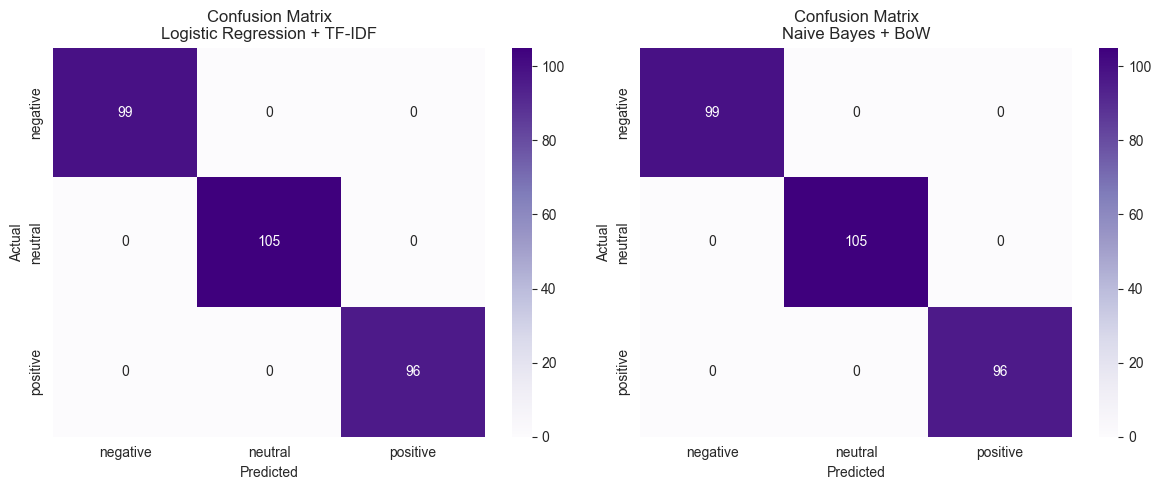

In [17]:
# Comparison
model_comparison = pd.DataFrame({
    'Model': ['Logistic Regression (TF-IDF)', 'Naive Bayes (Bag of Words)'],
    'Accuracy': [round(lr_acc, 4), round(nb_acc, 4)],
    'Weighted F1': [round(lr_f1, 4), round(nb_f1, 4)]
})
print(model_comparison.to_string(index=False))

# Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, preds, title in zip(axes, [lr_preds, nb_preds], 
                              ['Logistic Regression + TF-IDF', 'Naive Bayes + BoW']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
                xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
    ax.set_title(f'Confusion Matrix\n{title}')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig('results/model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
# Save evaluation CSV
eval_df = pd.DataFrame(
    classification_report(y_test, lr_preds, target_names=le.classes_, output_dict=True)
).T.round(4)
eval_df.to_csv('results/model_evaluation.csv')

# Save sample predictions
with open('results/sample_predictions.txt', 'w',encoding='utf-8') as f:
    f.write("Sample Predictions – TF-IDF + Logistic Regression\n")
    f.write("="*60 + "\n\n")
    test_texts = list(X_test)
    for i in range(15):
        actual = le.classes_[y_test.iloc[i]] if hasattr(y_test, 'iloc') else le.classes_[list(y_test)[i]]
        predicted = le.classes_[lr_preds[i]]
        status = "✓ CORRECT" if actual == predicted else "✗ WRONG"
        f.write(f"Text    : {test_texts[i][:80]}...\n")
        f.write(f"Actual  : {actual:<10} | Predicted: {predicted:<10} | {status}\n\n")
print("Evaluation files saved.")


Evaluation files saved.


## Task 5: Sequence Model – LSTM Architecture Design

While Logistic Regression performs well on this dataset (due to clear keyword signals), real-world customer support messages often require understanding of **word order and context**. An LSTM model is better suited for this.

### LSTM Architecture

```
Input: tokenized sequence of max length 50 tokens

Layer 1 – Embedding Layer
  vocab_size=5000, embedding_dim=64
  Maps each token ID to a dense 64-dimensional vector
  Captures semantic relationships between words

Layer 2 – LSTM Layer (128 units)
  Processes the sequence left-to-right
  Hidden state carries information from previous tokens
  Cell state provides long-term memory via forget/input/output gates

Layer 3 – Dropout (0.3)
  Regularization to prevent overfitting

Layer 4 – Dense (64, ReLU)
  Learns higher-level patterns from LSTM output

Layer 5 – Output Dense (3, Softmax)
  Outputs probability for each class: negative, neutral, positive

Loss: Categorical Cross-Entropy
Optimizer: Adam (lr=0.001)
Metric: Accuracy, F1-Score
```


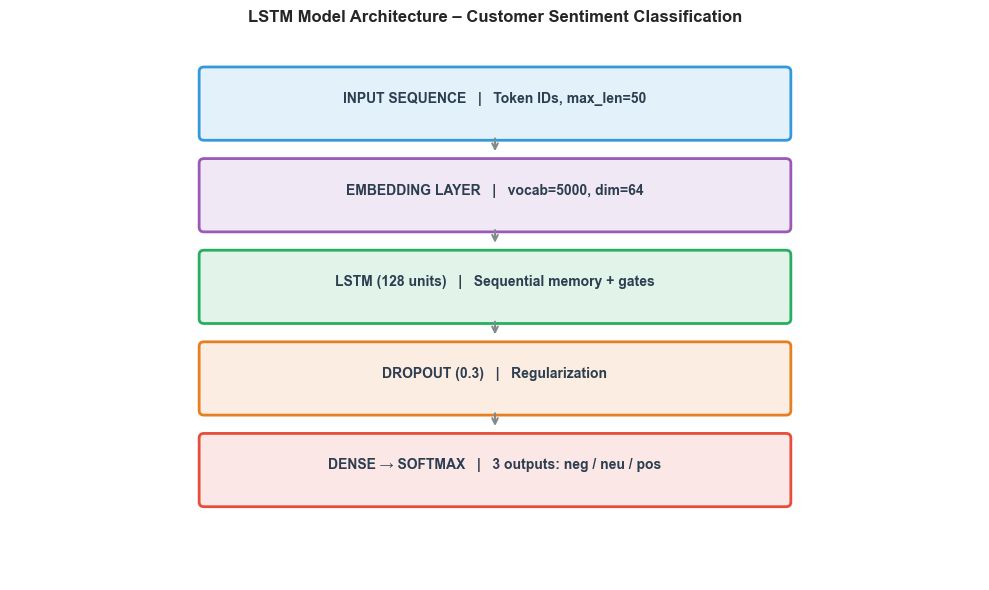

In [19]:
# Conceptual architecture diagram
fig, ax = plt.subplots(figsize=(10, 6))
ax.axis('off')
ax.set_xlim(0, 10); ax.set_ylim(0, 6)
ax.set_facecolor('#f8f9fa')

layers = [
    (5, 5.2, 'INPUT SEQUENCE', 'Token IDs, max_len=50', '#3498db'),
    (5, 4.2, 'EMBEDDING LAYER', 'vocab=5000, dim=64', '#9b59b6'),
    (5, 3.2, 'LSTM (128 units)', 'Sequential memory + gates', '#27ae60'),
    (5, 2.2, 'DROPOUT (0.3)', 'Regularization', '#e67e22'),
    (5, 1.2, 'DENSE → SOFTMAX', '3 outputs: neg / neu / pos', '#e74c3c'),
]
for x, y, title, detail, color in layers:
    from matplotlib.patches import FancyBboxPatch
    rect = FancyBboxPatch((x-3, y-0.35), 6, 0.7, boxstyle='round,pad=0.05',
                           linewidth=2, edgecolor=color, facecolor=color+'22')
    ax.add_patch(rect)
    ax.text(x, y+0.05, f'{title}   |   {detail}', ha='center', va='center',
            fontsize=10, color='#2c3e50', fontweight='bold')
    if y > 1.2:
        ax.annotate('', xy=(x, y-0.55), xytext=(x, y-0.35),
                    arrowprops=dict(arrowstyle='->', color='#7f8c8d', lw=1.5))

ax.set_title('LSTM Model Architecture – Customer Sentiment Classification', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


## Task 6: Attention and Transformer Reflection

### Why do RNNs struggle with long-term dependencies?

Standard RNNs process sequences step by step, passing a hidden state from one time step to the next. In a long sentence (e.g., 100+ words), the hidden state at the final step has been through 100 matrix multiplications. During backpropagation, gradients get multiplied by these same weights repeatedly — leading to **vanishing gradients** (gradients shrink toward 0) or **exploding gradients**. This means the model effectively "forgets" information from early in the sequence by the time it reaches the end.

### How do LSTMs help with memory?

LSTMs address this with a dedicated **cell state** — a separate memory track that runs alongside the hidden state. Three **gates** control information flow:
- **Forget gate** — decides what to erase from cell state
- **Input gate** — decides what new information to store
- **Output gate** — decides what part of cell state to pass as output

These gates are themselves learned from data, allowing the network to retain relevant information over hundreds of steps. This makes LSTMs far more effective at tasks like sentiment analysis on longer texts.

### What does attention solve in sequence-to-sequence tasks?

Even LSTMs struggle when output tokens need to refer back to specific input positions (e.g., in machine translation: "The cat sat" → "Die Katze saß"). The **attention mechanism** allows the decoder to dynamically look at **all encoder hidden states** at each decoding step, and assign weights (attention scores) to each one. This means the decoder can directly focus on the most relevant input words regardless of their distance — eliminating the bottleneck of compressing the entire input into a single fixed vector.

### Why are transformers important in modern NLP and Generative AI?

Transformers replace recurrence entirely with **self-attention** — where every token in a sequence attends to every other token simultaneously. This enables:
- **Full parallelization** during training (unlike RNNs which process sequentially)
- **Capturing global context** in a single pass
- **Scalability** — transformer performance keeps improving with more data and parameters

Models like BERT, GPT-4, and Claude are all transformer-based. They have redefined state-of-the-art for virtually every NLP task — from question answering to code generation — because they can be pre-trained on massive text corpora and fine-tuned for specific tasks with far less labeled data.
